# Task 1: Exploratory Data Analysis - Brent Oil Prices

**Objective:** Understand time series properties of Brent oil prices before modeling

This notebook performs exploratory analysis on Brent crude oil prices from 1987-2022, examining:
- Data quality and structure
- Trend analysis
- Stationarity testing
- Volatility patterns
- Distribution characteristics
- Visual correlation with major events

---

## 📦 Setup & Imports

In [33]:
import sys
import os
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Import our modular utilities
from src import analysis
from src import plots

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("✓ Libraries loaded successfully")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ Libraries loaded successfully
NumPy version: 2.0.1
Pandas version: 2.3.3


---
## 📊 Step 1: Load and Inspect Data

Load the Brent oil prices dataset and perform initial data quality checks.

In [34]:
# Load and prepare data using our utility function
df = analysis.load_and_prepare_data(
    file_path='../data/BrentOilPrices.csv',
    date_column='Date',
    price_column='Price'
)

# Display basic information
print("="*70)
print("DATASET OVERVIEW")
print("="*70)
print(f"\nDataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nData types:")
print(df.dtypes)
print("\n" + "="*70)

DATASET OVERVIEW

Dataset shape: (9011, 2)
Columns: ['Date', 'Price']

Data types:
Date     datetime64[ns]
Price           float64
dtype: object



In [35]:
# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

# Display first and last few rows
print("\n" + "="*70)
print("FIRST 5 ROWS:")
print("="*70)
print(df.head())

print("\n" + "="*70)
print("LAST 5 ROWS:")
print("="*70)
print(df.tail())


Missing Values:
Date     0
Price    0
dtype: int64

Total missing values: 0

FIRST 5 ROWS:
        Date  Price
0 1987-05-20  18.63
1 1987-05-21  18.45
2 1987-05-22  18.55
3 1987-05-25  18.60
4 1987-05-26  18.63

LAST 5 ROWS:
           Date  Price
9006 2022-11-08  96.85
9007 2022-11-09  93.05
9008 2022-11-10  94.25
9009 2022-11-11  96.37
9010 2022-11-14  93.59


### Parse Dates and Sort

In [36]:
# Date parsing and sorting already handled by load_and_prepare_data()
# Display date range
print("="*70)
print("DATE RANGE")
print("="*70)
print(f"Start date: {df['Date'].min().date()}")
print(f"End date:   {df['Date'].max().date()}")
print(f"Duration:   {(df['Date'].max() - df['Date'].min()).days} days")
print(f"Number of observations: {len(df):,}")
print("="*70)

DATE RANGE
Start date: 1987-05-20
End date:   2022-11-14
Duration:   12962 days
Number of observations: 9,011


## Save the prepared dataset into a new CSV file for modeling purposes.

In [37]:
df.to_csv('../data/BrentOilPrices_prepared.csv', index=False)

### Summary Statistics

In [39]:
# Generate summary statistics using our utility function
summary_stats = analysis.calculate_summary_statistics(df, price_column='Price')

print("\n" + "="*70)
print("PRICE SUMMARY STATISTICS")
print("="*70)
for key, value in summary_stats.items():
    print(f"{key}: {value}")
print("="*70)


PRICE SUMMARY STATISTICS
count: 9011
mean: 48.42078237709467
median: 38.57
std: 32.86010995167221
min: 9.1
max: 143.95
range: 134.85
cv: 67.86364932264416
skewness: 0.7653045224332095
kurtosis: -0.6104398901218313


---
## 📈 Step 2: Visualize Raw Price Series

Plot the complete time series to identify major trends, shocks, and patterns.

✓ Saved: ../outputs/task1_raw_prices.png


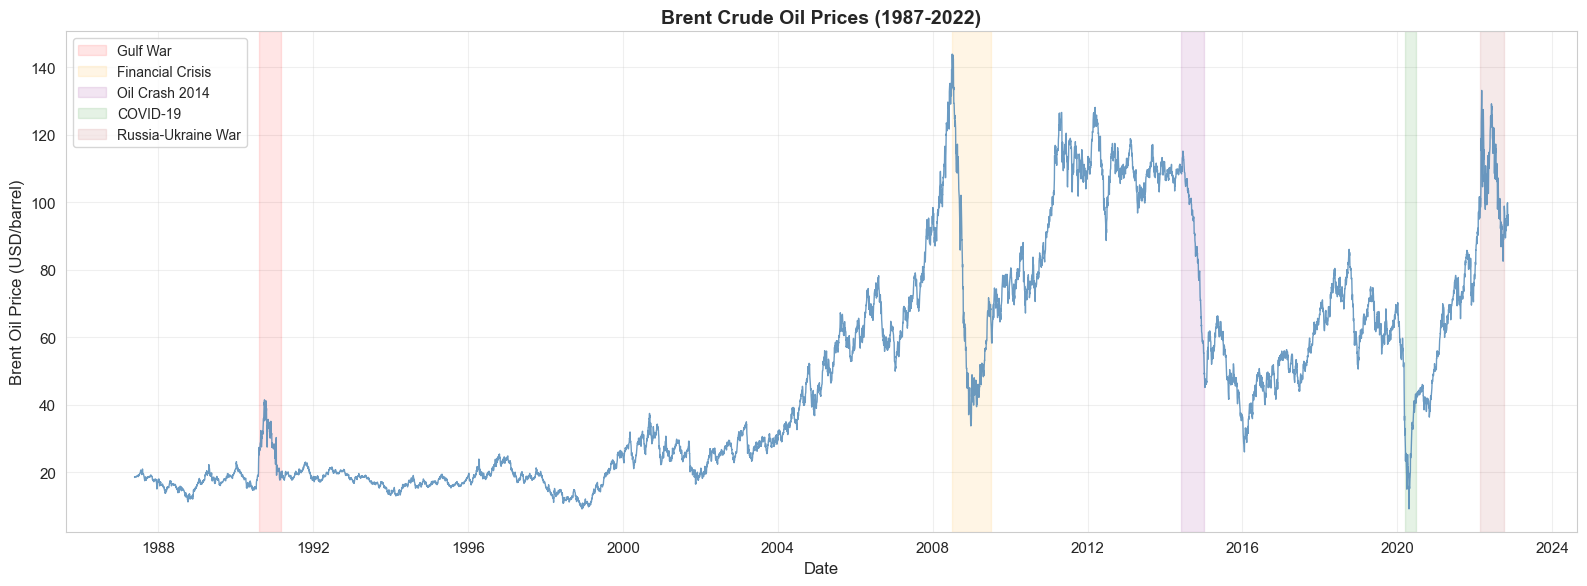

In [40]:
# Create output directory if it doesn't exist
os.makedirs('../outputs', exist_ok=True)

# Define major events for visualization (aligned with events.csv)
major_events = [
    ('Gulf War', '1990-08-02', '1991-02-28', 'red'),
    ('Financial Crisis', '2008-07-01', '2009-06-30', 'orange'),
    ('Oil Crash 2014', '2014-06-01', '2014-12-31', 'purple'),
    ('COVID-19', '2020-03-11', '2020-06-30', 'green'),
    ('Russia-Ukraine War', '2022-02-24', '2022-09-30', 'brown')
]

# Plot raw price series using modular function
plots.plot_raw_price_series(
    df=df,
    date_col='Date',
    price_col='Price',
    events=major_events,
    output_path='../outputs/task1_raw_prices.png',
    title='Brent Crude Oil Prices (1987-2022)'
)

### Observations from Raw Price Series

**Visual inspection reveals several distinct periods:**

1. **1987-1999**: Relatively low and stable prices (~$15-$25/barrel)
   - Brief spike during 1990-91 Gulf War
   - General stability despite Asian Financial Crisis

2. **2000-2008**: Strong upward trend (~$25 → $147/barrel)
   - Driven by growing emerging market demand (China, India)
   - Supply constraints and geopolitical tensions
   - Peak in July 2008 before financial crisis

3. **2008-2009**: Sharp crash (~$147 → $40/barrel)
   - Global Financial Crisis demand destruction
   - Fastest decline in oil price history

4. **2010-2014**: Recovery and high plateau (~$80-$120/barrel)
   - Post-crisis recovery
   - Arab Spring and Libya conflict maintained high prices
   - Relatively stable "new normal"

5. **2014-2016**: Another dramatic crash (~$115 → $30/barrel)
   - US shale revolution increased supply
   - OPEC refused to cut production (maintain market share strategy)
   - Oversupply conditions

6. **2016-2019**: Gradual recovery (~$30 → $70/barrel)
   - OPEC+ production cuts
   - Return to supply-demand balance

7. **2020**: COVID-19 crash (~$70 → $20/barrel)
   - Unprecedented demand destruction from global lockdowns
   - Saudi-Russia price war exacerbated decline
   - Brief period of negative WTI prices (Brent stayed positive)

8. **2021-2022**: Strong recovery and spike (~$20 → $120/barrel)
   - Post-pandemic demand recovery
   - Supply chain constraints
   - Russia-Ukraine war drove prices above $120

**Key insight:** Multiple regime shifts are clearly visible, suggesting multiple change points will be needed in Task 2.

---
## 📊 Step 3: Trend Analysis

Calculate and visualize rolling mean to identify long-term trends.

✓ Saved: ../outputs/task1_trend_analysis.png


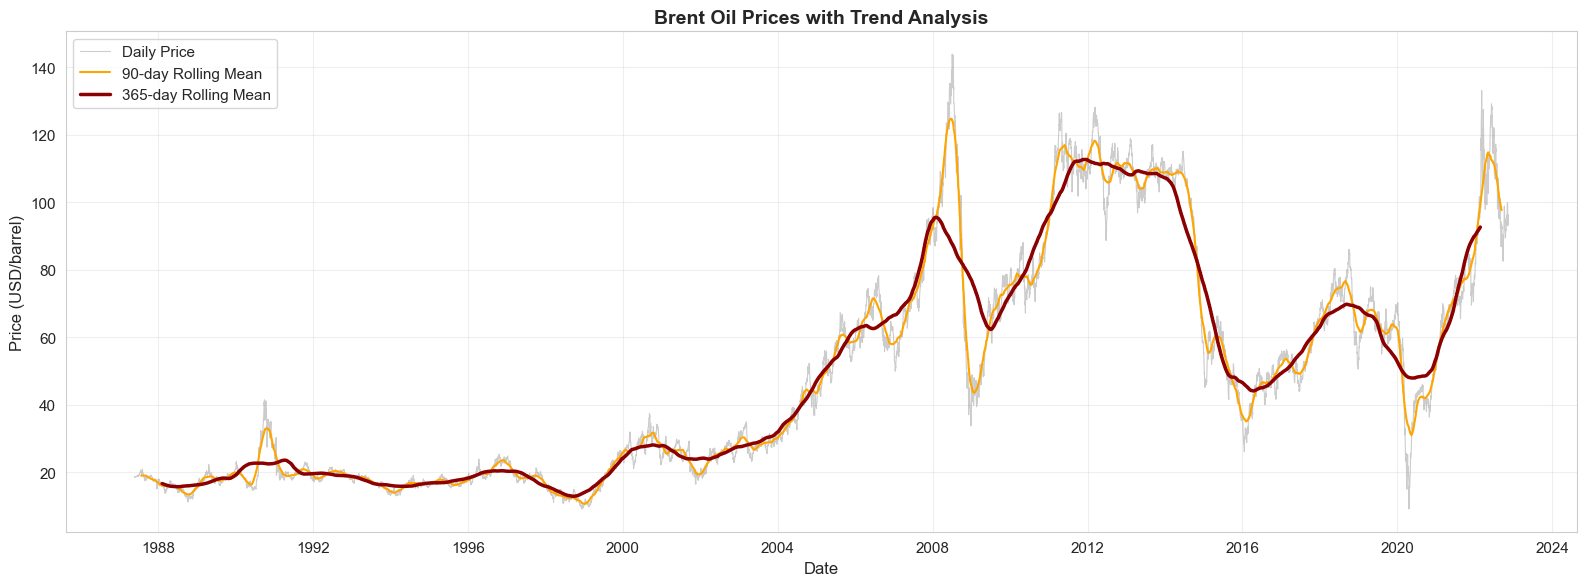

In [42]:
# Calculate rolling statistics using our utility function
df = analysis.calculate_rolling_statistics(
    df=df,
    price_column='Price',
    windows=[90, 365]
)

# Plot trend analysis using modular function
plots.plot_trend_analysis(
    df=df,
    date_col='Date',
    price_col='Price',
    rolling_cols=['rolling_mean_90', 'rolling_mean_365'],
    output_path='../outputs/task1_trend_analysis.png'
)

### Trend Analysis Findings

**The 365-day rolling mean reveals:**

1. **Non-linear trends**: The long-term trend is not a simple linear increase or decrease
2. **Multiple trend reversals**: Direction changes multiple times over the 35-year period
3. **Regime persistence**: Once established, trends tend to persist for 2-5 years before shifting
4. **Volatility around trend**: Daily prices oscillate around the trend with varying amplitudes
5. **Acceleration phases**: Some periods show accelerating trends (steep slopes) indicating momentum

**Implications for modeling:**
- Simple linear regression would be inadequate
- Multiple change points needed to capture trend shifts
- Regimes have different mean levels and potentially different volatilities

---
## 📉 Step 4: Stationarity Testing

Test whether the price series is stationary using the Augmented Dickey-Fuller (ADF) test.

**What is stationarity?**
- A stationary time series has constant mean, variance, and autocorrelation structure over time
- Non-stationary series have trends, changing variances, or other time-dependent properties
- Most statistical models (including our Bayesian change point model) require stationary data or appropriate transformations

**ADF Test:**
- Null hypothesis (H₀): Series is non-stationary (has a unit root)
- Alternative hypothesis (H₁): Series is stationary
- If p-value < 0.05, we reject H₀ and conclude the series is stationary

In [52]:
# Perform stationarity test using our utility function
adf_stats = analysis.perform_stationarity_test(
    series=df['Price'],
)

print("="*70)
print("STATIONARITY TEST: AUGMENTED DICKEY-FULLER")
print("="*70)
print(f"\nTest Statistic:     {adf_stats['test_statistic']:.6f}")
print(f"P-value:            {adf_stats['p_value']:.6f}")
print(f"Lags Used:          {adf_stats['lags_used']}")
print(f"Number of Obs:      {adf_stats['n_observations']}")

print(f"\nCritical Values:")
for key, value in adf_stats['critical_values'].items():
    print(f"  {key:>5}: {value:.6f}")

print("\n" + "-"*70)
if adf_stats['is_stationary']:
    print("✓ CONCLUSION: Series is STATIONARY (reject null hypothesis)")
    print("  The series has no unit root and exhibits mean reversion.")
else:
    print("✗ CONCLUSION: Series is NON-STATIONARY (fail to reject null hypothesis)")
    print("  The series has a unit root - mean and/or variance change over time.")

print("-"*70)

# Additional interpretation
if not adf_stats['is_stationary']:
    print("\n📌 IMPLICATIONS FOR MODELING:")
    print("  • Raw prices cannot be used directly in most statistical models")
    print("  • Transformation required to achieve stationarity")
    print("  • Common transformations:")
    print("    - First differences: price[t] - price[t-1]")
    print("    - Log returns: log(price[t]) - log(price[t-1])")
    print("    - Percentage changes: (price[t] - price[t-1]) / price[t-1]")
    print("\n  • In Task 2, we will use LOG RETURNS transformation")
    print("  • Log returns are approximately stationary and represent % changes")
    
print("\n" + "="*70)

STATIONARITY TEST: AUGMENTED DICKEY-FULLER

Test Statistic:     -1.993856
P-value:            0.289274
Lags Used:          29
Number of Obs:      8981

Critical Values:
     1%: -3.431078
     5%: -2.861862
    10%: -2.566941

----------------------------------------------------------------------
✗ CONCLUSION: Series is NON-STATIONARY (fail to reject null hypothesis)
----------------------------------------------------------------------

STATIONARITY TEST: AUGMENTED DICKEY-FULLER

Test Statistic:     -1.993856
P-value:            0.289274
Lags Used:          29
Number of Obs:      8981

Critical Values:
     1%: -3.431078
     5%: -2.861862
    10%: -2.566941

----------------------------------------------------------------------
✗ CONCLUSION: Series is NON-STATIONARY (fail to reject null hypothesis)
  The series has a unit root - mean and/or variance change over time.
----------------------------------------------------------------------

📌 IMPLICATIONS FOR MODELING:
  • Raw prices ca

### Why Stationarity Matters

**Non-stationary data causes problems:**
1. **Spurious relationships**: May detect correlations that don't actually exist
2. **Invalid inference**: Confidence intervals and hypothesis tests are unreliable
3. **Poor forecasting**: Models trained on non-stationary data don't generalize well
4. **Changing statistics**: Mean and variance aren't meaningful if they change over time

**Our finding: Raw Brent prices are NON-STATIONARY (as expected)**
- This is typical for financial prices which exhibit trends
- The mean price level has changed dramatically over time ($15 in 1990s → $100+ in recent years)
- Variance also appears to change (some periods more volatile than others)

**Solution for Task 2:**
- Transform prices to log returns: $r_t = \log(P_t) - \log(P_{t-1})$
- Log returns approximate percentage changes and are typically stationary
- Change point model will operate on log returns, not raw prices

---
## 📊 Step 5: Volatility Patterns

Analyze how price volatility (variability) changes over time.

**Volatility is important because:**
- Measures market uncertainty and risk
- Varies across different market regimes
- High volatility periods often coincide with major events
- "Volatility clustering" - high volatility periods tend to cluster together

✓ Saved: ../outputs/task1_volatility_patterns.png


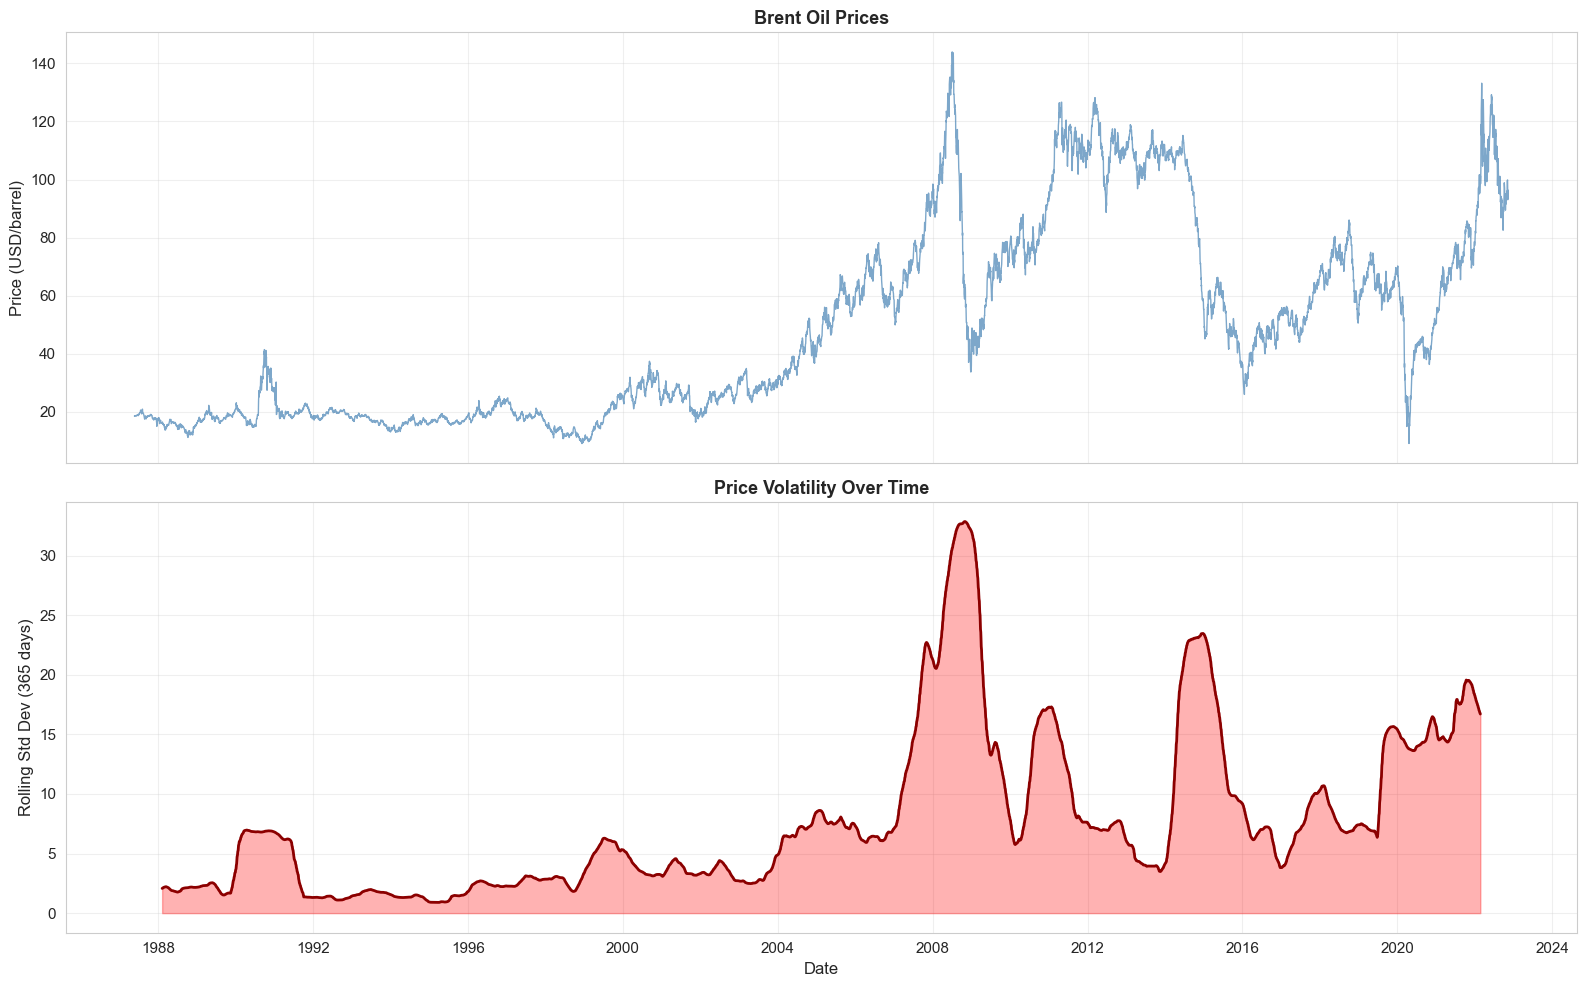

In [53]:
# Rolling statistics already calculated; now plot volatility analysis
plots.plot_volatility_analysis(
    df=df,
    date_col='Date',
    price_col='Price',
    volatility_col='rolling_std_365',
    output_path='../outputs/task1_volatility_patterns.png'
)

In [73]:
# Calculate summary statistics for different periods using utility function
print("="*70)
print("VOLATILITY ANALYSIS ACROSS PERIODS")
print("="*70)

periods = [
    ('1987-1999: Pre-2000s', '1987-01-01', '1999-12-31'),
    ('2000-2007: Rise Period', '2000-01-01', '2007-12-31'),
    ('2008-2009: Financial Crisis', '2008-01-01', '2009-12-31'),
    ('2010-2013: High Plateau', '2010-01-01', '2013-12-31'),
    ('2014-2016: Oil Crash', '2014-01-01', '2016-12-31'),
    ('2017-2019: Stabilization', '2017-01-01', '2019-12-31'),
    ('2020-2022: COVID & Ukraine', '2020-01-01', '2022-12-31'),
]

volatility_summary = []

for period_name, start, end in periods:
    stats = analysis.calculate_period_statistics(
        df=df,
        date_column='Date',
        price_column='Price',
       periods = periods
    )
    
  
    for i in range(len(stats)):
        print(f"\n{period_name}:")
        print(f"  Mean Price:  ${stats[i]['mean']:.2f}")
        print(f"  Std Dev:     ${stats[i]['std']:.2f}")
        print(f"  CV:          {stats[i]['cv']:.2f}%")
        print(f"  Observations: {stats[i]['n_obs']}")
        volatility_summary.append({
            'Period': period_name,
            'Mean': stats[i]['mean'],
            'StdDev': stats[i]['std'],
            'CV': stats[i]['cv'],
            'Observations': stats[i]['n_obs']
        })

print("\n" + "="*70)

VOLATILITY ANALYSIS ACROSS PERIODS

1987-1999: Pre-2000s:
  Mean Price:  $18.08
  Std Dev:     $4.00
  CV:          22.11%
  Observations: 3200

1987-1999: Pre-2000s:
  Mean Price:  $42.08
  Std Dev:     $18.84
  CV:          44.78%
  Observations: 2046

1987-1999: Pre-2000s:
  Mean Price:  $79.38
  Std Dev:     $28.35
  CV:          35.72%
  Observations: 505

1987-1999: Pre-2000s:
  Mean Price:  $102.69
  Std Dev:     $14.94
  CV:          14.55%
  Observations: 1001

1987-1999: Pre-2000s:
  Mean Price:  $64.93
  Std Dev:     $26.44
  CV:          40.73%
  Observations: 764

1987-1999: Pre-2000s:
  Mean Price:  $63.22
  Std Dev:     $9.02
  CV:          14.26%
  Observations: 766

1987-1999: Pre-2000s:
  Mean Price:  $70.60
  Std Dev:     $27.04
  CV:          38.30%
  Observations: 729

2000-2007: Rise Period:
  Mean Price:  $18.08
  Std Dev:     $4.00
  CV:          22.11%
  Observations: 3200

2000-2007: Rise Period:
  Mean Price:  $42.08
  Std Dev:     $18.84
  CV:          44.78

### Volatility Findings

**Key observations:**

1. **Volatility clusters**: High volatility periods are followed by high volatility (not random)
2. **Regime-dependent volatility**: Different price regimes have different volatility levels
3. **Crisis amplification**: Major events (2008 crisis, 2014 crash, COVID) show extreme volatility spikes
4. **Mean reversion**: After volatility spikes, markets tend to return to calmer states

**Highest volatility periods:**
- 2008-2009: Financial crisis
- 2014-2016: Oil price crash
- 2020: COVID-19 and price war

**Lowest volatility periods:**
- Early 1990s: Stable low-price environment
- 2010-2013: High plateau period

**Implications:**
- Bayesian model may benefit from regime-specific volatility parameters
- High volatility periods likely align with change points
- Volatility itself could be a signal for regime shifts

---
## 📊 Step 6: Distribution Analysis

Examine the statistical distribution of oil prices to understand data characteristics.

✓ Saved: ../outputs/task1_distribution.png


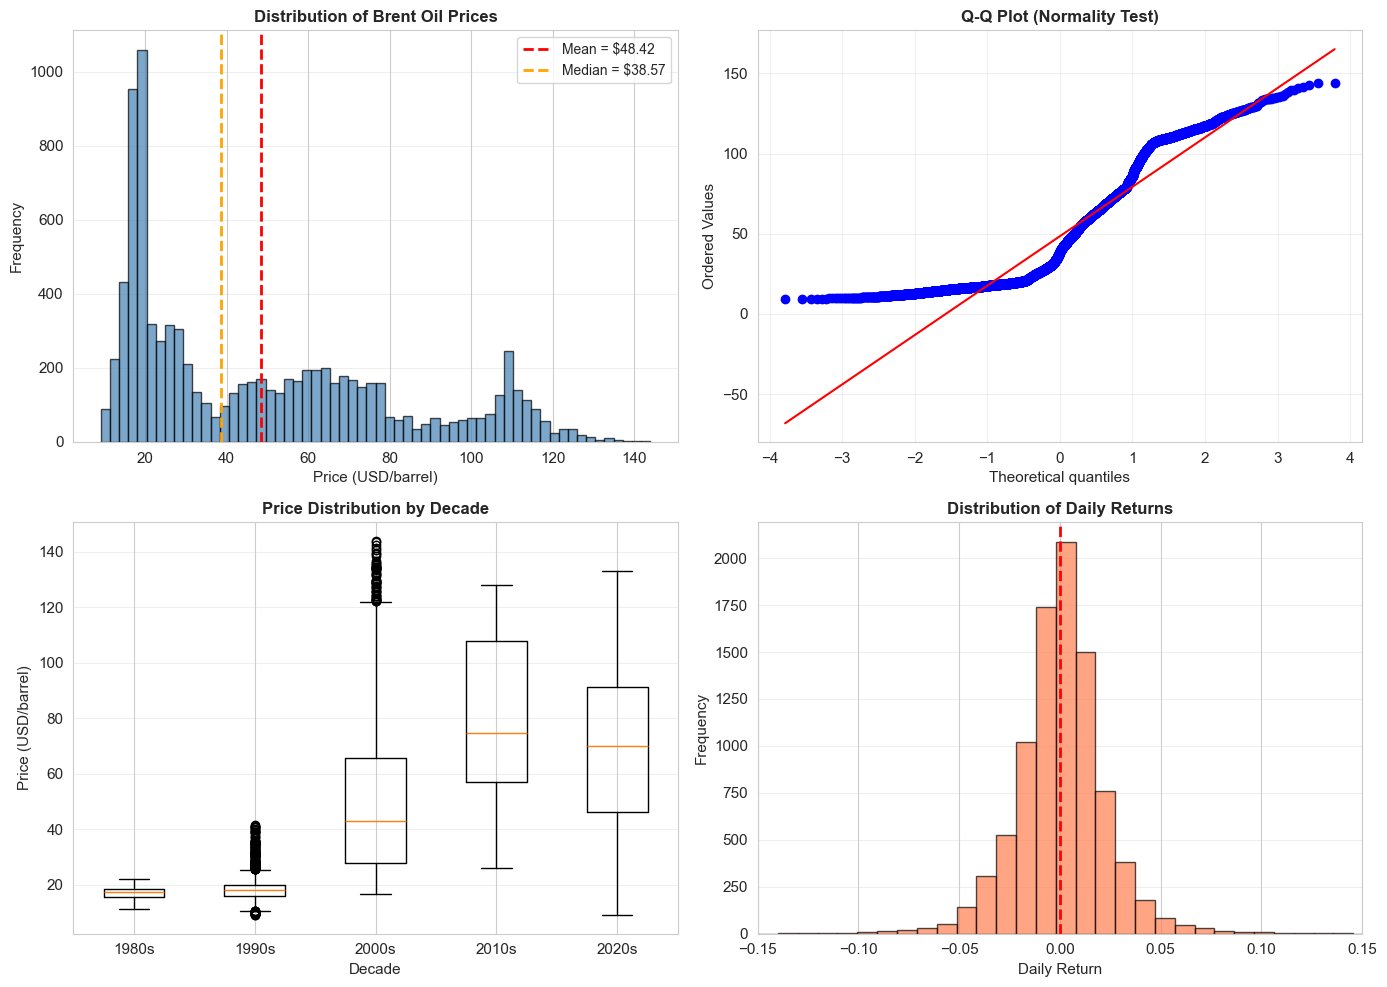

In [77]:
# Calculate daily returns first
df = analysis.calculate_returns(df, price_column='Price')

# Create distribution analysis plots using modular function
plots.plot_distribution_analysis(
    df=df,
    price_col='Price',
    return_col='daily_return',
    output_path='../outputs/task1_distribution.png'
)

In [88]:
# Analyze distribution using utility function
dist_stats = analysis.analyze_distribution(series=df['Price'])

print("="*70)
print("DISTRIBUTION STATISTICS")
print("="*70)

print("\nPRICE DISTRIBUTION:")
print(f"  Mean:       ${dist_stats['mean']:.2f}")
print(f"  Median:     ${dist_stats['median']:.2f}")
print(f"  Std Dev:    ${dist_stats['std']:.2f}")
print(f"  Skewness:   {dist_stats['skewness']:.4f}")
print(f"  Kurtosis:   {dist_stats['kurtosis']:.4f}")

print(f"\nShapiro-Wilk Normality Test:")
print(f"  is normal: {dist_stats['is_normal']:.6f}")
print(f"  shapiro_stat:        {dist_stats['shapiro_stat']:.6f}")
print(f" shapiro p-value:        {dist_stats['shapiro_pvalue']:.6f}")
if dist_stats['shapiro_pvalue'] < 0.05:
    print(f"  Conclusion:     NOT normally distributed (reject normality)")
else:
    print(f"  Conclusion:     Approximately normal (fail to reject normality)")

print("\n" + "-"*70)

# Check for extreme returns

extreme_info = analysis.check_extreme_returns(returns=df['daily_return'])
print(f"\n  Extreme returns (> {extreme_info['threshold']:.4f} std dev): {extreme_info['n_extreme']}")
print(f"  Percentage:                    {extreme_info['pct_extreme']:.2f}%")
print(f"  (Normal distribution: ~0.3%)")

print("\n" + "="*70)

DISTRIBUTION STATISTICS

PRICE DISTRIBUTION:
  Mean:       $48.42
  Median:     $38.57
  Std Dev:    $32.86
  Skewness:   0.7653
  Kurtosis:   -0.6104

Shapiro-Wilk Normality Test:
  is normal: 0.000000
  shapiro_stat:        0.878620
 shapiro p-value:        0.000000
  Conclusion:     NOT normally distributed (reject normality)

----------------------------------------------------------------------

  Extreme returns (> 0.0758 std dev): 106
  Percentage:                    1.18%
  (Normal distribution: ~0.3%)



### Distribution Analysis Findings

**Raw Prices:**
- **Right-skewed**: Mean > Median, indicating a long right tail
- **NOT normally distributed**: Q-Q plot shows departure from normal line, especially in tails
- **Bimodal tendency**: Histogram suggests multiple "humps" - evidence of different regimes
- **Changing statistics over time**: Box plots by decade show mean and variance shift

**Daily Returns:**
- **Approximately symmetric**: Close to zero mean
- **Fat tails (leptokurtic)**: More extreme values than normal distribution predicts
- **Excess kurtosis**: Kurtosis > 3 indicates heavy tails
- This is typical of financial asset returns

**Why This Matters:**
1. **Raw prices are NOT suitable for Normal distribution models** (used in many statistical methods)
2. **Log returns are more appropriate** - closer to symmetric, stationary
3. **Student's t distribution may be better than Normal** for modeling returns (handles fat tails)
4. **Multiple modes in price histogram support multiple change points hypothesis**

---
## 🔗 Step 7: Event Overlay Analysis

Load the events database and overlay events on the price chart to visualize temporal correlations.

In [89]:
# Load events database
events_df = pd.read_csv('../data/events.csv')
events_df['start_date'] = pd.to_datetime(events_df['start_date'])
events_df['end_date'] = pd.to_datetime(events_df['end_date'])

print("="*70)
print("EVENTS DATABASE LOADED")
print("="*70)
print(f"\nTotal events: {len(events_df)}")
print(f"\nEvent categories:")
print(events_df['category'].value_counts())

print("\n" + "-"*70)
print("EVENTS LIST:")
print("-"*70)
for idx, row in events_df.iterrows():
    print(f"\n{idx+1}. {row['event_name']} ({row['category']})")
    print(f"   Period: {row['start_date'].date()} to {row['end_date'].date()}")
    print(f"   Description: {row['description'][:80]}...")

print("\n" + "="*70)

EVENTS DATABASE LOADED

Total events: 15

Event categories:
category
geopolitical    5
supply_shock    4
economic        3
policy          3
Name: count, dtype: int64

----------------------------------------------------------------------
EVENTS LIST:
----------------------------------------------------------------------

1. Gulf War (geopolitical)
   Period: 1990-08-02 to 1991-02-28
   Description: Iraq invasion of Kuwait led to international military response and disruption of...

2. Asian Financial Crisis (economic)
   Period: 1997-07-02 to 1998-12-31
   Description: Regional economic collapse in East Asia reduced oil demand and caused global mar...

3. 9/11 Terror Attacks (geopolitical)
   Period: 2001-09-11 to 2001-10-31
   Description: Terrorist attacks on United States caused immediate market shock and uncertainty...

4. Iraq War (geopolitical)
   Period: 2003-03-20 to 2003-05-01
   Description: US-led invasion of Iraq disrupted oil production and created supply concerns in ...


✓ Saved: outputs/task1_prices_with_events.png


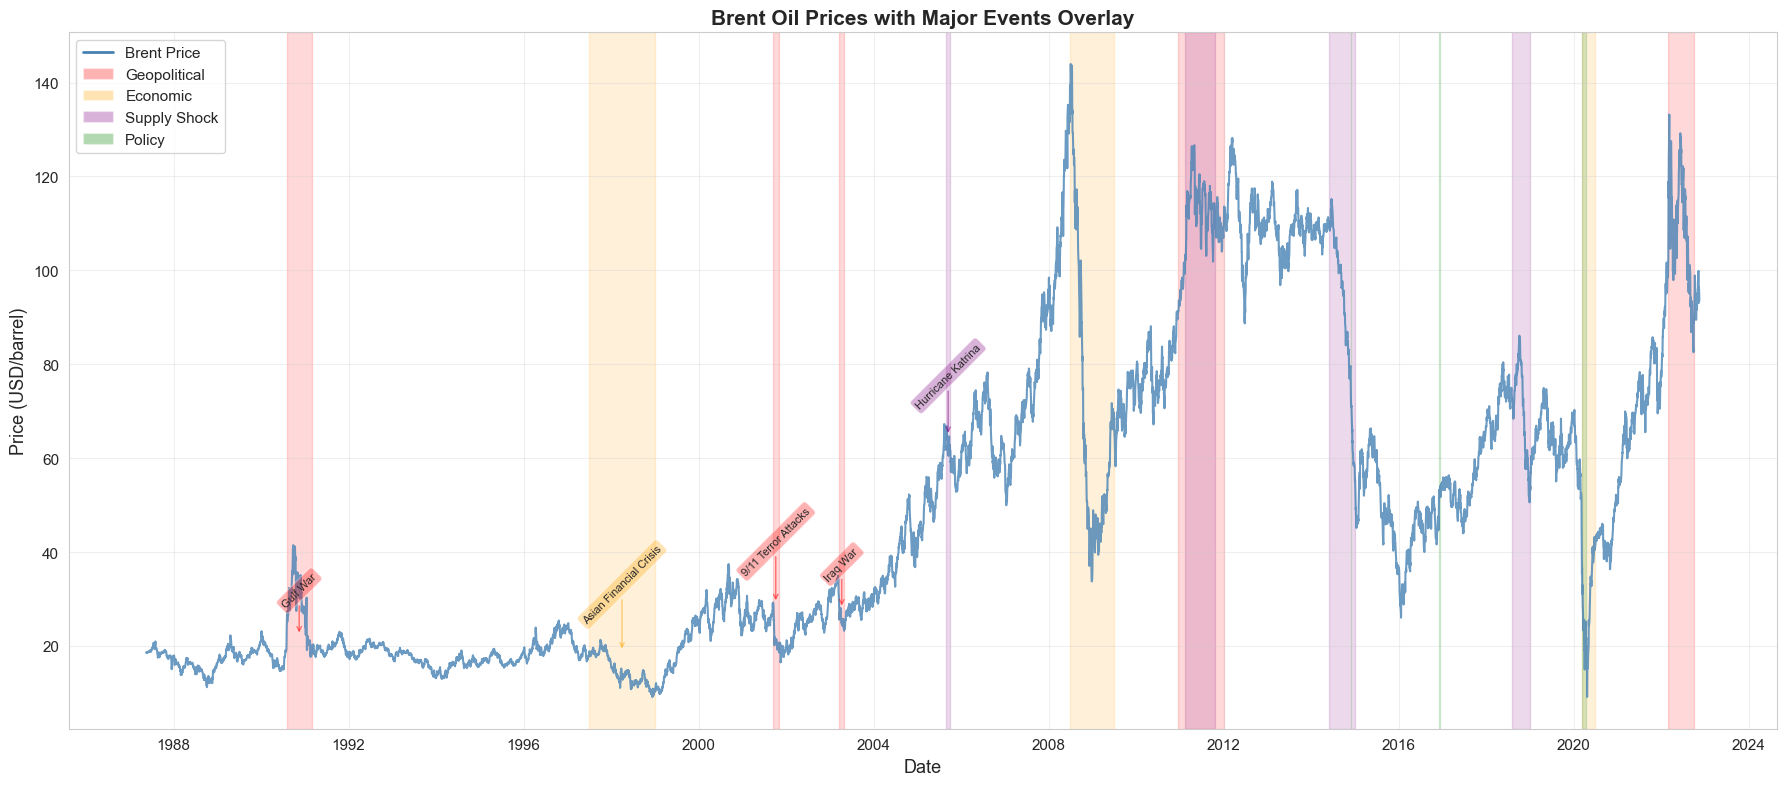

In [ ]:
# Create price chart with event overlays using modular function
plots.plot_events_overlay(
    df=df,
    events_df=events_df,
    date_col='Date',
    price_col='Price',
    output_path='../outputs/task1_prices_with_events.png'
)

### Event-Price Correlation Observations

**Visual inspection suggests temporal correlation between several events and price movements:**

**1. Gulf War (1990-91)**
- Event coincides with sharp price spike
- Supply disruption from Kuwait/Iraq region
- Prices returned to baseline after war ended

**2. Asian Financial Crisis (1997-98)**
- Associated with price decline
- Demand destruction from regional economic collapse

**3. Global Financial Crisis (2008-09)**
- Dramatic price crash from peak ~$147 to ~$40
- Demand destruction from global recession
- Most significant price movement in dataset

**4. Shale Revolution & OPEC Decision (2014)**
- Marks beginning of major price decline
- OPEC's decision not to cut production accelerated crash
- Structural shift in supply dynamics

**5. COVID-19 & Saudi-Russia Price War (2020)**
- Unprecedented demand shock combined with supply flood
- Prices briefly dropped below $20
- Fastest crash since 2008

**6. Russia-Ukraine War (2022)**
- Sharp price spike to >$120
- Supply concerns and sanctions on Russian energy
- Energy crisis in Europe

**Important Caveats:**
- ⚠️ **Temporal correlation ≠ causation**
- Multiple events can contribute to single price movement
- Market reactions may be delayed (lag between event and price response)
- Some price movements may have no clear external cause (market dynamics)
- Visual correlation is suggestive but requires statistical testing (Task 2)

---
## 📋 Step 8: Summary of Findings

Consolidate all exploratory analysis results and document implications for modeling.

In [90]:
# Generate comprehensive summary report using utility function
analysis.print_summary_report(
    df=df,
    stationarity_result=adf_stats,
    dist_stats=dist_stats,
    events_df=events_df,
 
)

print("\n📁 DELIVERABLES SAVED:")
print("  ✓ PLAN.md - Analysis workflow and methodology documentation")
print("  ✓ data/events.csv - Curated database of 15 major events")
print("  ✓ outputs/task1_raw_prices.png")
print("  ✓ outputs/task1_trend_analysis.png")
print("  ✓ outputs/task1_volatility_patterns.png")
print("  ✓ outputs/task1_distribution.png")
print("  ✓ outputs/task1_prices_with_events.png")
print("\n🎯 NEXT PHASE: Task 2 - Bayesian Change Point Modeling")


                    EDA SUMMARY REPORT

📊 DATA QUALITY:
  ✓ Dataset contains 9,011 daily observations
  ✓ Date range: 1987-05-20 to 2022-11-14
  ✓ Duration: 12,962 days
  ✓ Missing values: 907
  ✓ Price range: $9.10 - $143.95

📉 STATIONARITY:
  • ADF Test P-value: 0.289274
  • Conclusion: NON-STATIONARY
  • ⚡ ACTION REQUIRED: Transform to log returns

📊 DISTRIBUTION:
  • Mean: $48.42
  • Skewness: 0.765
  • Kurtosis: -0.610
  • Normality (Shapiro-Wilk p-value): 0.000000
  • Distribution: NOT normal
  • ⚡ RECOMMENDATION: Use Student's t distribution

🔗 EVENT CORRELATION:
  • Compiled database: 15 major events
  • Event categories:
    - Geopolitical: 5
    - Supply Shock: 4
    - Economic: 3
    - Policy: 3



📁 DELIVERABLES SAVED:
  ✓ PLAN.md - Analysis workflow and methodology documentation
  ✓ data/events.csv - Curated database of 15 major events
  ✓ outputs/task1_raw_prices.png
  ✓ outputs/task1_trend_analysis.png
  ✓ outputs/task1_volatility_patterns.png
  ✓ outputs/task1_distribu

---
## 📝 Conclusions

This exploratory analysis establishes the foundation for Bayesian change point modeling in Task 2.

### Key Takeaways:

1. **Data Quality**: Excellent - 35 years of clean daily data
2. **Non-Stationarity Confirmed**: Raw prices require log return transformation
3. **Multiple Regimes Evident**: 6-8 distinct periods visible from visual inspection
4. **Volatility Clustering**: High and low volatility periods cluster together
5. **Fat-Tailed Returns**: Student's t distribution preferred over Normal
6. **Event Correlation**: Strong visual correlation between major events and price shifts
7. **Complexity Required**: Multiple change point model necessary

### Ready for Task 2:

With this comprehensive understanding of the data's statistical properties, we're well-prepared to:
- Transform data appropriately (log returns)
- Specify priors informed by EDA findings
- Choose appropriate likelihood distribution
- Interpret detected change points with domain knowledge
- Attribute regime shifts to causal events with appropriate caution

---

**Analysis completed:** February 12, 2026  
**Analyst:** Mariam Gustavo, 10 Academy